In [112]:
# Bibliotheken & Konstanten
import pandas as pd
import matplotlib.pyplot as plt
import scipy.signal as signal
import scipy.fft
import numpy as np

PATH = "./data/gel augen zu besser/augen_zu.csv"
#PATH = "./data/gel augen zu besser/augen-zu-raw.csv"
CHANNELS = {
    "EEG 1": "Fz",
    "EEG 2": "C3",
    "EEG 3": "Cz",
    "EEG 4": "C4",
    "EEG 5": "C4",
    "EEG 6": "PO7",
    "EEG 7": "Oz",
    "EEG 8": "PO8"
}
SAMPLE_FREQ = 250 #Hz


In [113]:
# Daten laden
# - unbrauchbare Daten am Anfang abschneiden

df = pd.read_csv(filepath_or_buffer= PATH,
                 sep = ',',
                 header=0,
                 usecols=[0,1,2,3,4,5,6,7,9]
                 #usecols=list(range(0, 8))   # ergibt [0, 1, 2, 3, 4, 5, 6, 7]
                 )

df = df.rename(columns= lambda x: x.strip())
#print(df.columns.tolist())


# schaue wann die Daten != 0 sind)
# Vektorisierung: Operation auf die gesamte Struktur gleichzeitig
# df[BEDINGUNG]
df_clean_start = df[(df != 0).all(axis=1)]
print(df_clean_start)

       EEG 1  EEG 2  EEG 3  EEG 4   EEG 5  EEG 6   EEG 7  EEG 8      CNT
242    0.283 -0.120 -0.120  0.003   0.004  0.145   0.001 -0.145    243.0
243    0.512 -0.216 -0.216  0.018   0.005  0.232   0.010 -0.250    244.0
244    0.758 -0.316 -0.317  0.061   0.001  0.264   0.039 -0.339    245.0
245    0.943 -0.383 -0.399  0.153  -0.019  0.177   0.096 -0.358    246.0
246    1.003 -0.391 -0.464  0.315  -0.082 -0.027   0.175 -0.288    247.0
...      ...    ...    ...    ...     ...    ...     ...    ...      ...
20867  1.814  0.662  3.770 -0.691  -9.651 -3.157  11.638  9.910  20868.0
20868  2.959 -1.589  4.288  0.227 -10.664 -4.519   8.490  7.897  20869.0
20869  3.969 -2.737  4.235  2.236 -10.086 -4.675   4.586  5.958  20870.0
20870  5.157 -2.676  3.931  4.351  -7.813 -3.118   1.176  4.956  20871.0
20871  6.674 -1.824  3.787  5.574  -4.504 -0.031  -0.947  5.175  20872.0

[20624 rows x 9 columns]


### Gelerntes
**Nr.1:** vergiss nicht zu re-assignen!

```df = df.rename(columns= lambda x: x.strip())```

hier wurde zB nichts angezeicht bevor ich output df = .. habe

**Nr.2:**
DataFrame.rename
mapper >  *function transformations to apply to that axis’ values. Use either mapper and axis to specify the axis to target with mapper, or index and columns*.

-------------------------------------------------------------------------------------------
### UPCOMING STEP ON MY WAY TO MASTERING EEG
- [x] Roh EEG plotten
- [ ] Oz, PO7, PO8 (EEG Channels 6-8): Power Spectrum

plot(x, y)


<Figure size 640x480 with 0 Axes>

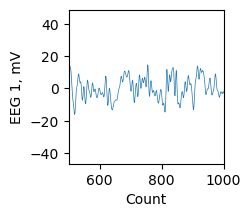

In [114]:
fig = plt.figure(  )
fig, ax = plt.subplots(figsize=( 2, 2))
ax.set_xlabel("Count")
ax.set_ylabel("EEG 1, mV")
ax.set_xlim(500, 1000)
ax.plot(df_clean_start["CNT"] , df_clean_start["EEG 1"], linewidth=0.5)
plt.show()

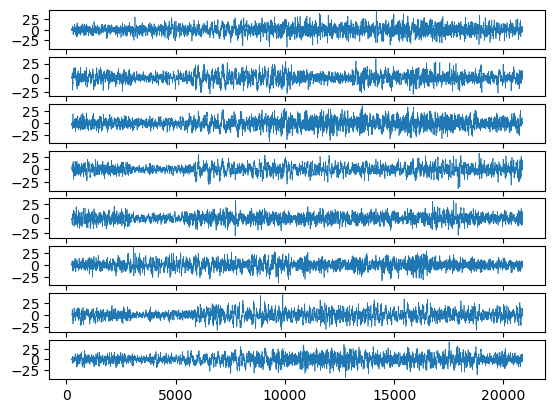

In [115]:
#mehrere Plots

fig_all, axs = plt.subplots(len(df.columns)-1)
for i in range(1, len(df.columns)):
    axs[i-1].plot (df_clean_start["CNT"] , df_clean_start[f"EEG {i}"], linewidth=0.5)


## DC-Offset + Bandpass + Notchfilter

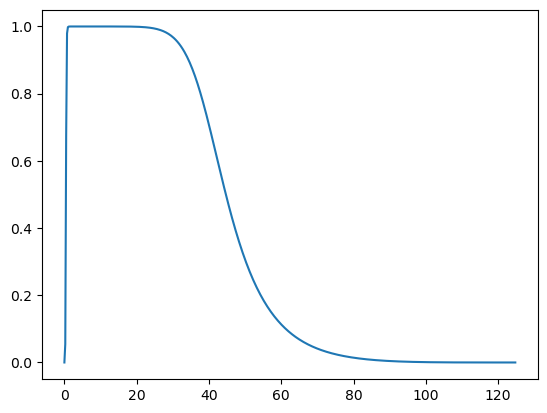

In [110]:
# ------------------------ BANDPASSFILTER ANWENDEN
# Koeffizienten b (Zaehler) und a (Nennen) der Filter-Uebertragungsfunktion werden berechnet
b, a = signal.butter ( 4, [0.5, 40], fs=SAMPLE_FREQ, btype = "band",
                      output="ba")

# Zur Kontrolle: Sanity-Check Visualisierung als Kurve
w, h = signal.freqz (b, a, fs=SAMPLE_FREQ)
plt.plot(w, np.abs(h))

# FIR/ IIR Filter auf die Daten anwenden
df_bandfiltered = signal.lfilter (b, a, df_clean_start["EEG 8"])


##### Frequenzbaender erkennen
*Calculating the power spectrum of an EEG signal after applying a Butterworth filter 
involves running a Fast Fourier Transform (FFT) or Power Spectral Density (PSD) estimation
 to evaluate frequency band distributions like alpha or beta waves.*
 - FFT: split data in windows, compute FFT, square the absolute values of the FFT coefficients and average them across windows to get PSD
 - Power Spectral Density

Es gibt kein scipy.signal.fft sondern scipy.fft!

<img src="./screenshots/korrektur.png" width="660" height="500"/>

The output is a set of complex numbers, one for each frequency bin. Each complex number has two parts:

- Magnitude (or amplitude): how strong that frequency is in the signal
- Phase: where in its cycle that frequency was at the start of the window

To get power, you square the magnitude. Power spectral density (PSD) plots show power (magnitude squared) on the y-axis and frequency on the x-axis. This is the bread-and-butter output of EEG frequency analysis.

Quelle: https://neurosity.co/guides/fast-fourier-transform-fft-eeg-analysis-primer

Fragen:
- Was bedeuten negative komplexe Zahlen?
- Nachdem ich FFT auf window (500 Samples) angewendet habe 
```freq = fft(window)```
und dann ```freq``` ausgegeben habe, kam 500 raus. Aber warum ist Anzahl der Frequenzen in freq genau so lang wie window?
In jedem 500 Sample Windows soll es quasi 500 Frequenzen geben? Random Zufall irgendwie..

Theorie:

Magnitude: 
1. ```r = wurzel(real^2 + imaginaer^2)``` <--- Pythagoras Theorem!!!
2. ```abs(complex_number, /)```
**Return the absolute value of a number. ... If the argument is a complex number,
its magnitude is returned.*

Magnitude and Amplitude are not the same!

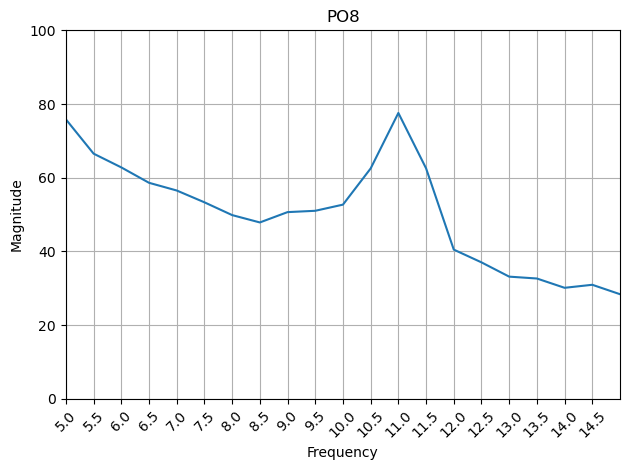

In [119]:
from scipy.fft import fft
import cmath #fuer komplexe zahlen

# ---------------------- SPEKTRUM VISUALISIEREN
# WINDOW SIZE: 500 Samples = 2 sec => 0.5Hz Unterschied erkennen
# input: df_bandfiltered (ES IST SCHON EEG 8.CHANNEL!)
windows_size = 500
n_windows = len(df_bandfiltered) // windows_size
df_truncated = df_bandfiltered[:n_windows*windows_size]

fft_average = np.zeros(shape=(windows_size,),
                            dtype="float64") #complex128
# WICHTIG: "apply a Hanning Window"
hann_window = signal.windows.hann(500)

for w in range(n_windows):
    #nimm w.te windows_size Datenpunkte
    window = df_truncated[w*windows_size : (w*windows_size + windows_size)]
    filtered_window = window * hann_window
    freq = np.fft.fft(filtered_window)

# magnitude: r = wurzel(real^2 + imaginaer^2)
# ODER abs(number, /)
# Return the absolute value of a number. ... If the argument is a complex number,
# its magnitude is returned.
    freq_squared = np.abs(freq) # magnitude 
    fft_average += freq_squared

fft_average = fft_average / windows_size # durchscnitt

frequencies = np.fft.fftfreq(500, 1/250)

# Keep only positive frequencies
positive_frequencies = frequencies[frequencies > 0]
#print(positive_frequencies)
positive_fft_values = fft_average[frequencies > 0]

# Plot
plt.plot(positive_frequencies, positive_fft_values)
plt.grid(visible=True)
plt.title("PO8")
plt.xticks(np.arange(5, 15, 0.5), rotation=45)  # von 5 bis 30, Schrittweite 1
plt.xlabel("Frequency")
plt.ylabel("Magnitude")
plt.xlim(5,15)
plt.ylim(0,100)
plt.tight_layout()
plt.show()
# To get power, you square the magnitude. Power spectral density (PSD) plots show 
# power (magnitude squared) on the y-axis and frequency on the x-axis

![WARUM SIEHT ES SO KOMISCH AUS](./screenshots/fft_windowing.png)